In [1]:
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
import seaborn as sns

In [2]:
# ── 1. Load dataset ──────────────────────────────────────────────────────────
data = pd.read_csv("/content/drive/MyDrive/Dataset/A_Z Handwritten Data.csv").astype('float32')
X = data.drop('0', axis=1)
y = data['0']

In [3]:
# ── 2.Split Dataset into Train / Test ────────────────────────────────────────────────────
train_x, test_x, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)
train_x = np.reshape(train_x.values, (train_x.shape[0], 28, 28))
test_x  = np.reshape(test_x.values,  (test_x.shape[0],  28, 28))
print("Train data shape:", train_x.shape)
print("Test  data shape:", test_x.shape)

Train data shape: (297960, 28, 28)
Test  data shape: (74490, 28, 28)


In [4]:
# ── 3. Label dictionary ──────────────────────────────────────────────────────
word_dict = {i: chr(65 + i) for i in range(26)}

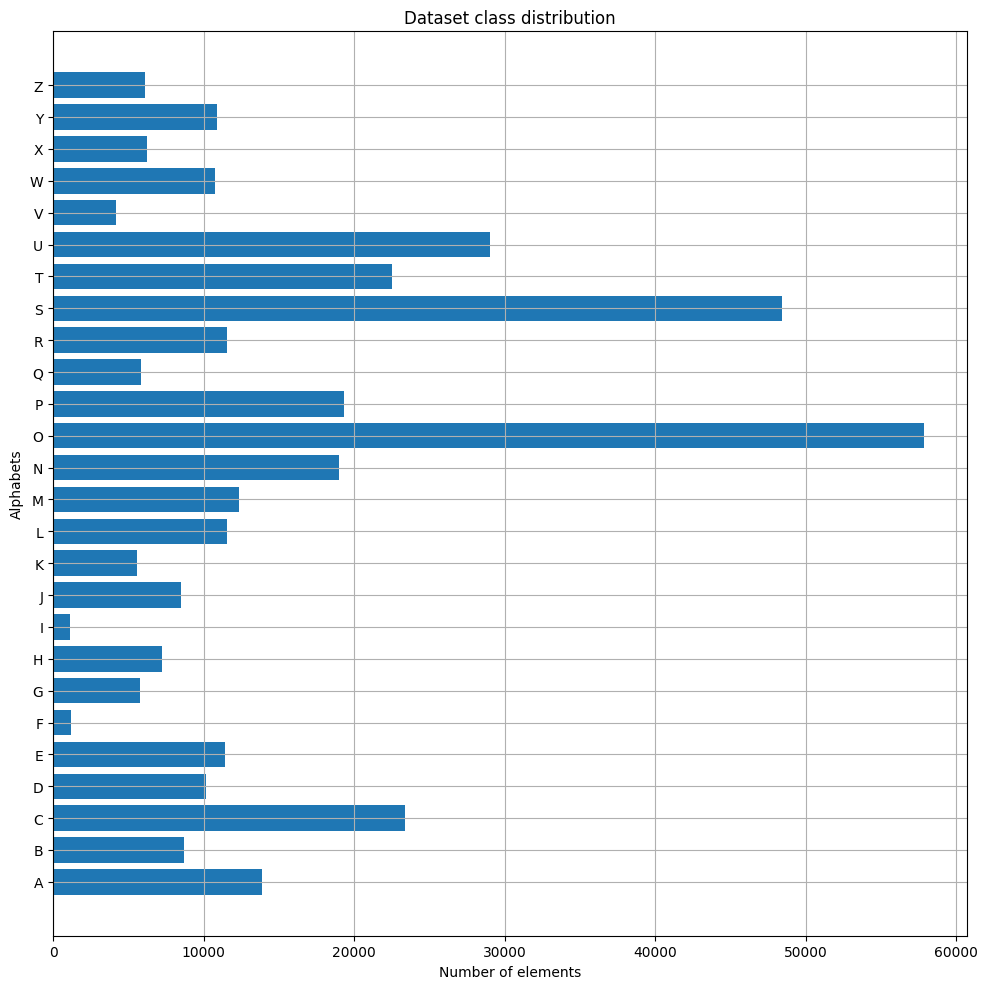

In [5]:
# ── 4. Class distribution plot ───────────────────────────────────────────────
train_yint = y.astype(int)
count      = np.bincount(train_yint, minlength=26)
alphabets  = list(word_dict.values())
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(alphabets, count)
plt.xlabel("Number of elements")
plt.ylabel("Alphabets")
plt.title("Dataset class distribution")
plt.grid()
plt.tight_layout()
plt.show()

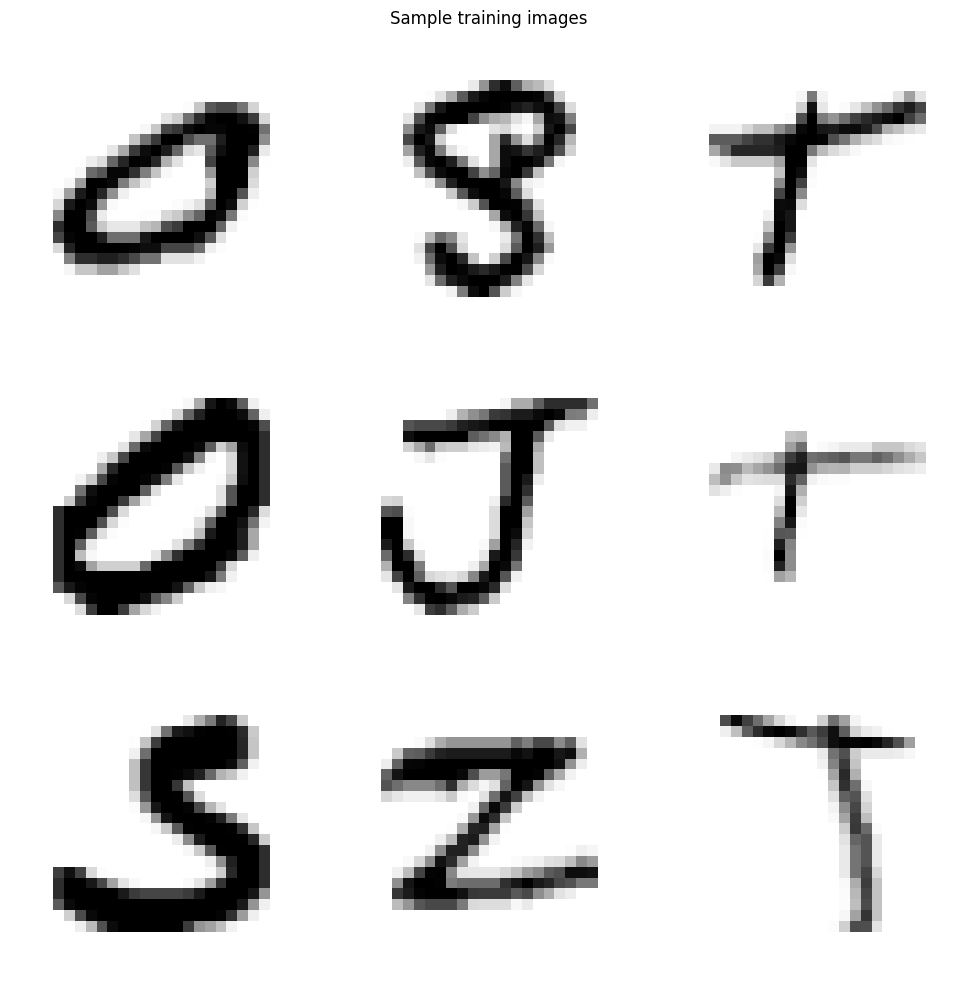

In [6]:
# ── 5. Preview shuffled samples ──────────────────────────────────────────────
shuff = shuffle(train_x[:100])
fig, ax = plt.subplots(3, 3, figsize=(10, 10))
axes = ax.flatten()
for i in range(9):
    axes[i].imshow(np.reshape(shuff[i], (28, 28)), cmap="Greys")
    axes[i].axis('off')
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()

In [7]:
# ── 6. Add channel dim + NORMALIZE to [0, 1] ────────────────────────────────
#    the external image preprocessing. Without this the model sees a completely
#    different value range at prediction time → wrong predictions guaranteed.
train_X = train_x.reshape(train_x.shape[0], 28, 28, 1) / 255.0
test_X  = test_x.reshape(test_x.shape[0],  28, 28, 1) / 255.0
print("New shape of train data:", train_X.shape)
print("New shape of test  data:", test_X.shape)

New shape of train data: (297960, 28, 28, 1)
New shape of test  data: (74490, 28, 28, 1)


In [8]:
# ── 7. One-hot encode labels ─────────────────────────────────────────────────
train_yOHE = to_categorical(train_y, num_classes=26)
test_yOHE  = to_categorical(test_y,  num_classes=26)
print("Train labels shape:", train_yOHE.shape)
print("Test  labels shape:", test_yOHE.shape)

Train labels shape: (297960, 26)
Test  labels shape: (74490, 26)


In [9]:
# ── 8. Build CNN ─────────────────────────────────────────────────────────────
model = Sequential([
    Conv2D(32,  (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPool2D((2, 2), strides=2),
    Conv2D(64,  (3, 3), activation='relu', padding='same'),
    MaxPool2D((2, 2), strides=2),
    Conv2D(128, (3, 3), activation='relu', padding='valid'),
    MaxPool2D((2, 2), strides=2),
    Flatten(),
    Dense(64,  activation='relu'),
    Dense(128, activation='relu'),
    Dense(26,  activation='softmax'),
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,178 (535.85 KB)

 Trainable params: 137,178 (535.85 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ── 9. Train ─────────────────────────────────────────────────────────────────
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, min_lr=0.0001)
early_stop = EarlyStopping(monitor='val_loss', min_delta=0, patience=2, verbose=1, mode='auto')
history = model.fit(
    train_X, train_yOHE,
    epochs=10,
    batch_size=256,
    callbacks=[reduce_lr, early_stop],
    validation_data=(test_X, test_yOHE)
)

Epoch 1/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9306 - loss: 0.2452 - val_accuracy: 0.9785 - val_loss: 0.0778 - learning_rate: 0.0010
Epoch 2/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9812 - loss: 0.0670 - val_accuracy: 0.9838 - val_loss: 0.0590 - learning_rate: 0.0010
Epoch 3/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9858 - loss: 0.0505 - val_accuracy: 0.9881 - val_loss: 0.0456 - learning_rate: 0.0010
Epoch 4/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9882 - loss: 0.0408 - val_accuracy: 0.9859 - val_loss: 0.0509 - learning_rate: 0.0010
Epoch 5/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9941 - loss: 0.0218 - val_accuracy: 0.9921 - val_loss: 0.0305 - learning_rate: 2.0000e-04
Epoch 6/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9952 - loss: 0.0179 - val_accuracy: 0.9920 - val_loss: 0.0308 - learning_rate: 2.0000e-04
Epoch 7/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy

In [11]:
# ─: Save model to custom path ─────────────────────────────────
model_dir = "/content/drive/MyDrive/Models/CNN_Model"
os.makedirs(model_dir, exist_ok=True)
# Save the model
model_path = os.path.join(model_dir, "model.h5")
model.save(model_path)
print(f" Model saved to: {model_path}")

 Model saved to: /content/drive/MyDrive/Models/CNN_Model/model.h5


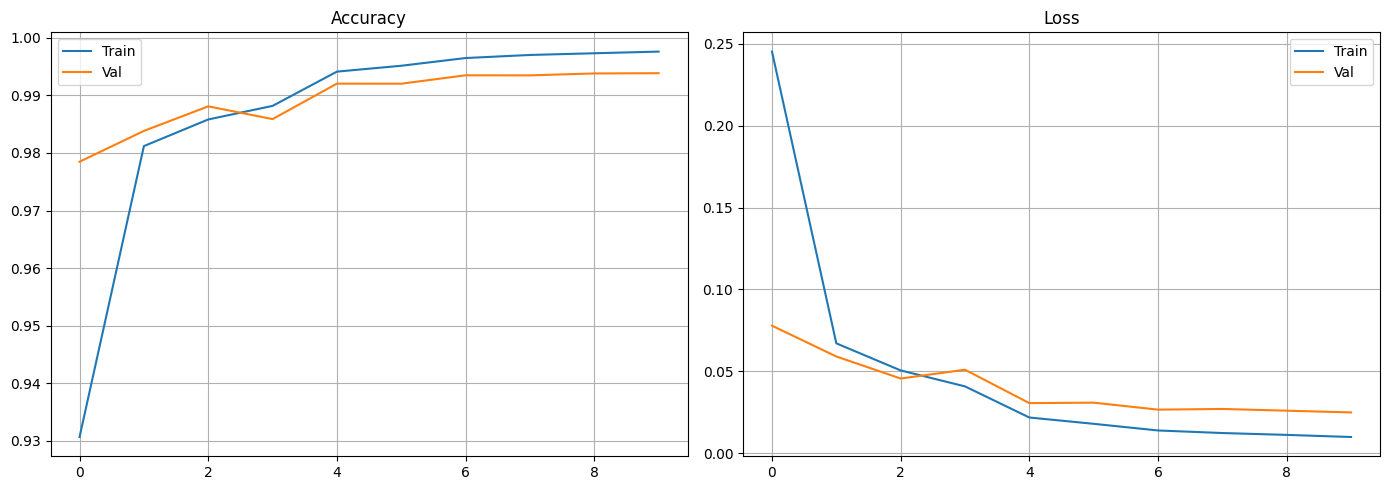

Validation accuracy: [0.978480339050293, 0.9838367700576782, 0.9881057739257812, 0.9858907461166382, 0.9920526146888733, 0.9920392036437988, 0.9935024976730347, 0.9934890866279602, 0.9938246607780457, 0.9938649535179138]
Training   accuracy: [0.930638313293457, 0.9811954498291016, 0.9858269691467285, 0.9881863594055176, 0.9941401481628418, 0.9951604008674622, 0.9965028762817383, 0.9970365166664124, 0.9973318576812744, 0.9976204633712769]
Validation loss    : [0.07782662659883499, 0.059020474553108215, 0.04556557163596153, 0.050934743136167526, 0.030547911301255226, 0.030832564458251, 0.02656145766377449, 0.02698187343776226, 0.025922926142811775, 0.024858811870217323]
Training   loss    : [0.24520020186901093, 0.06704724580049515, 0.050510160624980927, 0.04076224938035011, 0.021757906302809715, 0.017904065549373627, 0.013843389227986336, 0.012279985472559929, 0.011146929115056992, 0.009853891097009182]


In [12]:
# ── 10. Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy');  axes[0].legend();  axes[0].grid()
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss');  axes[1].legend();  axes[1].grid()
plt.tight_layout()
plt.show()
print("Validation accuracy:", history.history['val_accuracy'])
print("Training   accuracy:", history.history['accuracy'])
print("Validation loss    :", history.history['val_loss'])
print("Training   loss    :", history.history['loss'])

In [14]:
# ── 11. CHANGE #2: Comprehensive Test Evaluation ──────────────────────────────
print("\n" + "="*80)
print("COMPREHENSIVE TEST DATASET EVALUATION")
print("="*80)
# Get predictions on entire test set
test_predictions = model.predict(test_X, verbose=0)
test_pred_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_yOHE, axis=1)


COMPREHENSIVE TEST DATASET EVALUATION


In [15]:
# Overall Accuracy
test_accuracy = accuracy_score(test_true_classes, test_pred_classes)
print(f"\n📊 Overall Test Accuracy: {test_accuracy * 100:.2f}%")


📊 Overall Test Accuracy: 99.39%


In [16]:
# Per-class Accuracy
print("\n📈 Per-Class Accuracy:")
print("-" * 50)
for i in range(26):
    mask = test_true_classes == i
    if mask.sum() > 0:
        class_accuracy = accuracy_score(
            test_true_classes[mask],
            test_pred_classes[mask]
        )
        char = word_dict[i]
        print(f"   {char}: {class_accuracy * 100:6.2f}%  ({mask.sum()} samples)")


📈 Per-Class Accuracy:
--------------------------------------------------
   A:  99.68%  (2806 samples)
   B:  99.16%  (1673 samples)
   C:  99.58%  (4742 samples)
   D:  97.85%  (2044 samples)
   E:  99.46%  (2214 samples)
   F:  97.40%  (231 samples)
   G:  98.56%  (1183 samples)
   H:  98.43%  (1466 samples)
   I:  97.47%  (237 samples)
   J:  98.74%  (1668 samples)
   K:  99.20%  (1132 samples)
   L:  98.97%  (2319 samples)
   M:  99.56%  (2487 samples)
   N:  99.49%  (3756 samples)
   O:  99.55%  (11629 samples)
   P:  99.46%  (3868 samples)
   Q:  99.05%  (1159 samples)
   R:  99.35%  (2296 samples)
   S:  99.71%  (9556 samples)
   T:  99.75%  (4447 samples)
   U:  99.76%  (5860 samples)
   V:  99.88%  (823 samples)
   W:  98.82%  (2198 samples)
   X:  98.98%  (1269 samples)
   Y:  98.82%  (2202 samples)
   Z:  99.67%  (1225 samples)


In [20]:
# Classification Report
print("\n Classification Report:")
print("-" * 50)
class_names = [word_dict[i] for i in range(26)]
print(classification_report(test_true_classes, test_pred_classes, target_names=class_names, digits=3))


 Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

           A      0.993     0.997     0.995      2806
           B      0.996     0.992     0.994      1673
           C      0.994     0.996     0.995      4742
           D      0.976     0.978     0.977      2044
           E      0.996     0.995     0.995      2214
           F      0.996     0.974     0.985       231
           G      0.975     0.986     0.980      1183
           H      0.992     0.984     0.988      1466
           I      0.983     0.975     0.979       237
           J      0.989     0.987     0.988      1668
           K      0.991     0.992     0.992      1132
           L      0.993     0.990     0.991      2319
           M      0.991     0.996     0.993      2487
           N      0.994     0.995     0.995      3756
           O      0.996     0.996     0.996     11629
           P      0.996     0.995     0.995      3868
     


 Confusion Matrix (first 10x10):
--------------------------------------------------
Full confusion matrix shape: (26, 26)


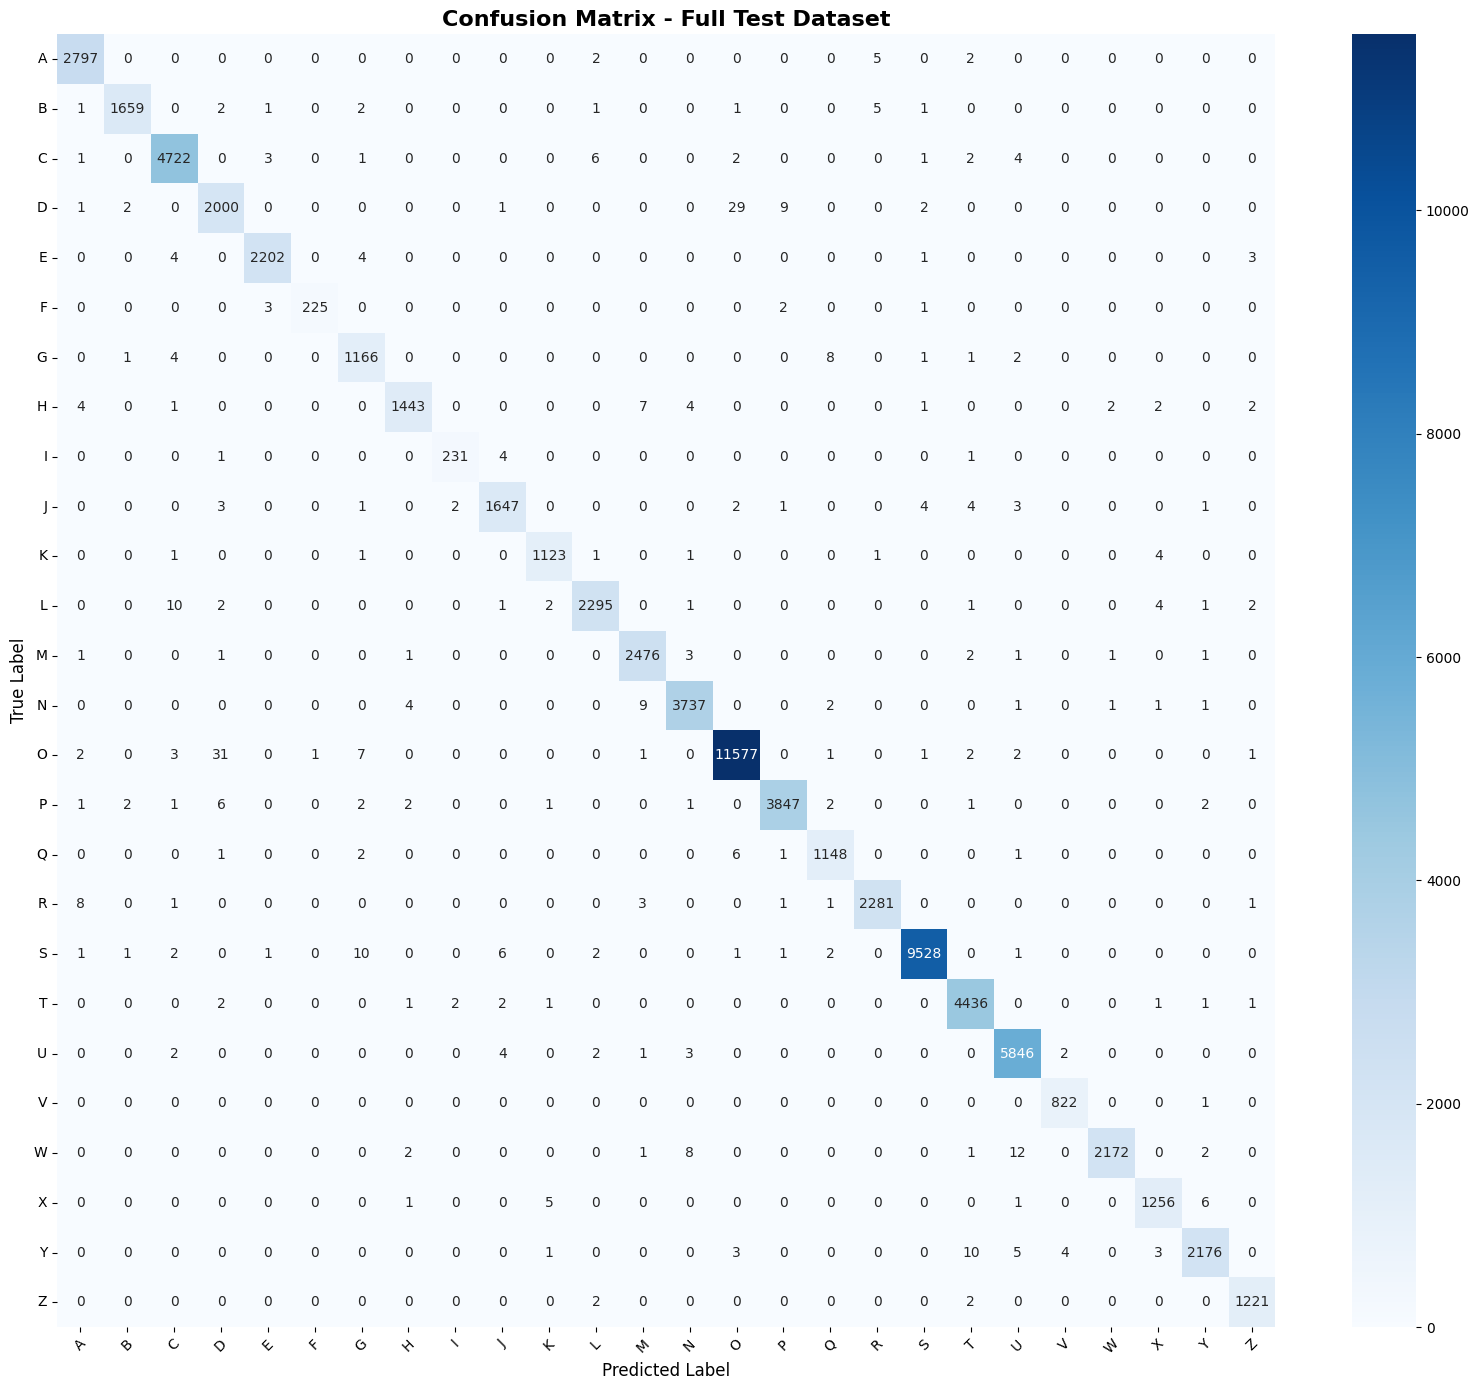

In [21]:
# Confusion Matrix
print("\n Confusion Matrix (first 10x10):")
print("-" * 50)
cm = confusion_matrix(test_true_classes, test_pred_classes)
print("Full confusion matrix shape:", cm.shape)
# Plot full CM
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.title('Confusion Matrix - Full Test Dataset', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


 Confidence Statistics:
--------------------------------------------------
   Mean Confidence: 99.45%
   Median Confidence: 100.00%
   Min Confidence: 18.04%
   Max Confidence: 100.00%
   Std Dev: 3.84%


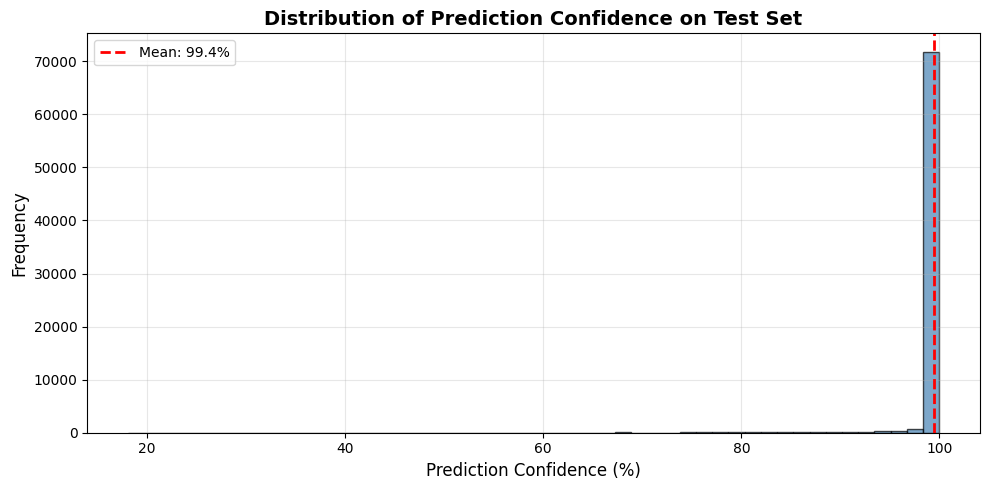

In [22]:
# Confidence Distribution
print("\n Confidence Statistics:")
print("-" * 50)
max_confidences = np.max(test_predictions, axis=1) * 100
print(f"   Mean Confidence: {np.mean(max_confidences):.2f}%")
print(f"   Median Confidence: {np.median(max_confidences):.2f}%")
print(f"   Min Confidence: {np.min(max_confidences):.2f}%")
print(f"   Max Confidence: {np.max(max_confidences):.2f}%")
print(f"   Std Dev: {np.std(max_confidences):.2f}%")
# Plot CD
plt.figure(figsize=(10, 5))
plt.hist(max_confidences, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Prediction Confidence (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Confidence on Test Set', fontsize=14, fontweight='bold')
plt.axvline(np.mean(max_confidences), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(max_confidences):.1f}%')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


 Misclassified Samples: 457 out of 74490 (0.61%)


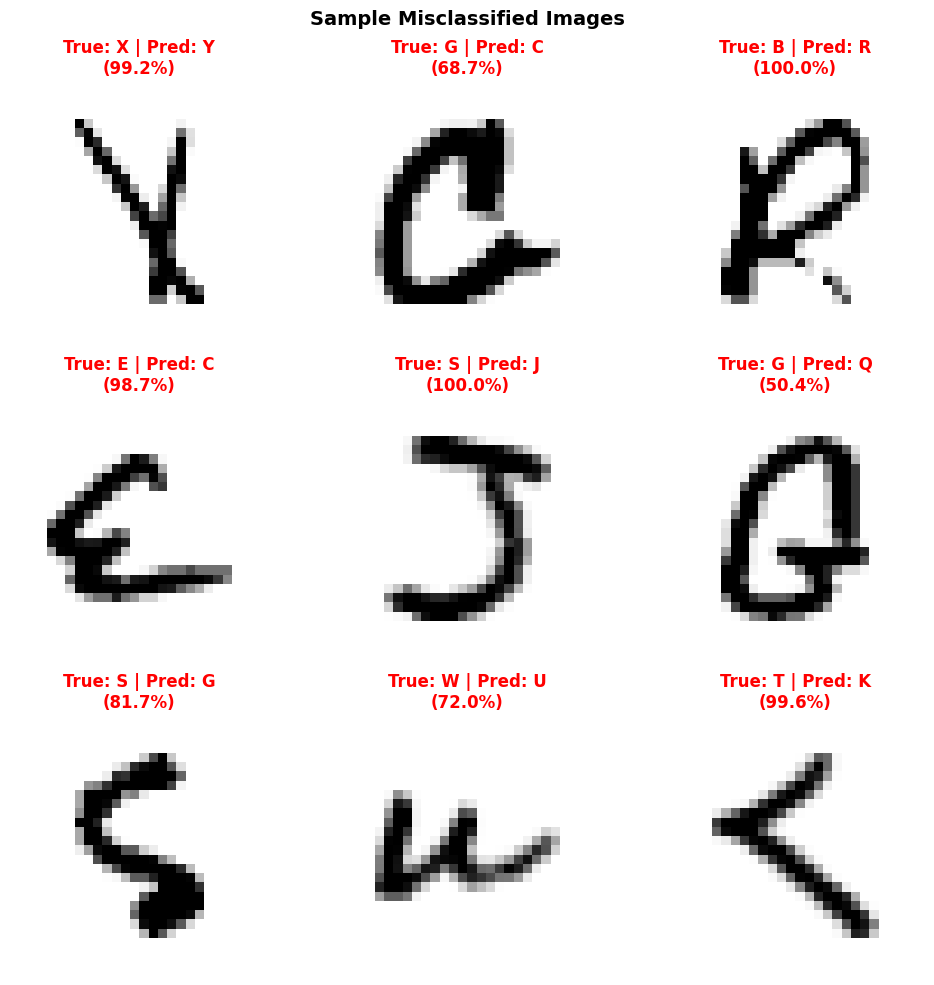


✅ TEST EVALUATION COMPLETE



In [23]:
# Misclassified samples analysis
misclassified_mask = test_true_classes != test_pred_classes
num_misclassified = misclassified_mask.sum()
print(f"\n Misclassified Samples: {num_misclassified} out of {len(test_true_classes)} ({num_misclassified/len(test_true_classes)*100:.2f}%)")
# Show 9 misclassified samples
if num_misclassified > 0:
    misclassified_indices = np.where(misclassified_mask)[0]
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()
    for i, idx in enumerate(misclassified_indices[:9]):
        img = test_X[idx].reshape(28, 28)
        axes[i].imshow(img, cmap="Greys")
        true_char = word_dict[test_true_classes[idx]]
        pred_char = word_dict[test_pred_classes[idx]]
        confidence = max_confidences[idx]
        axes[i].set_title(f"True: {true_char} | Pred: {pred_char}\n({confidence:.1f}%)",color='red', fontweight='bold')
        axes[i].axis('off')
    # Hide unused subplots
    for i in range(9, len(axes)):
        axes[i].axis('off')
    plt.suptitle("Sample Misclassified Images", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
print("\n" + "="*80)
print("✅ TEST EVALUATION COMPLETE")
print("="*80 + "\n")

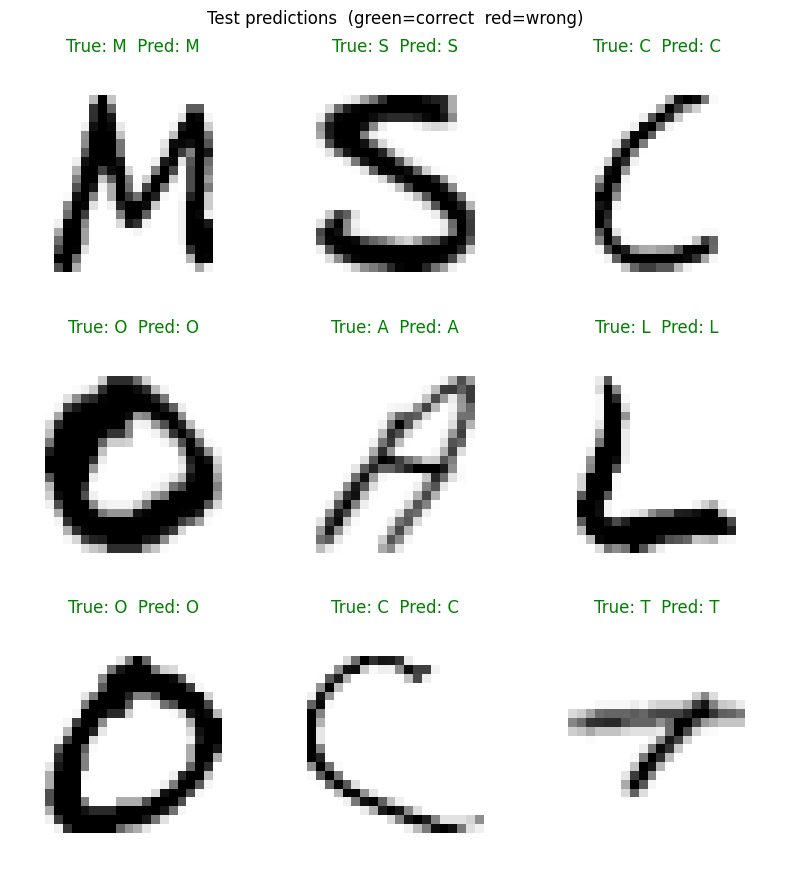

In [24]:
# ── 12. Predict on 9 test samples ────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(8, 9))
axes = axes.flatten()
for i, ax in enumerate(axes):
    img = np.reshape(test_X[i], (28, 28))
    ax.imshow(img, cmap="Greys")
    true_lbl = word_dict[np.argmax(test_yOHE[i])]
    pred_lbl = word_dict[np.argmax(model.predict(test_X[i:i+1], verbose=0))]
    ax.set_title(f"True: {true_lbl}  Pred: {pred_lbl}",color='green' if true_lbl == pred_lbl else 'red')
    ax.axis('off')
plt.suptitle("Test predictions  (green=correct  red=wrong)")
plt.tight_layout()
plt.show()

Predicted character : S  (confidence: 100.0%)


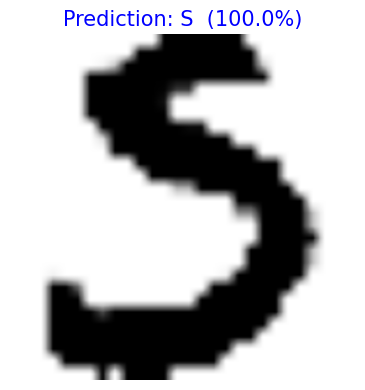

In [25]:
# ── 13. Predict on external image ────────────────────────────────────────────
img_raw = cv2.imread("/content/drive/MyDrive/test_caracter/caracter.png", cv2.IMREAD_GRAYSCALE)
if img_raw is None:
    print("Image not found — check the path.")
else:
    # threshold on FULL-SIZE image first, then resize to 28×28.
    _, img_thresh = cv2.threshold(img_raw, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # Make sure the character is WHITE on BLACK (matches training data)
    if np.mean(img_thresh) > 127:
        img_thresh = cv2.bitwise_not(img_thresh)
    img_28 = cv2.resize(img_thresh, (28, 28))
    # normalize to [0,1] exactly as training data
    img_final = img_28.reshape(1, 28, 28, 1) / 255.0
    # Predict
    pred      = model.predict(img_final, verbose=0)
    img_pred  = word_dict[np.argmax(pred)]
    confidence = np.max(pred) * 100
    print(f"Predicted character : {img_pred}  (confidence: {confidence:.1f}%)")
    # Display with matplotlib (cv2.imshow not supported in Colab)
    img_display = cv2.resize(img_28, (280, 280))
    plt.figure(figsize=(4, 4))
    plt.imshow(img_display, cmap='Greys')
    plt.title(f"Prediction: {img_pred}  ({confidence:.1f}%)", fontsize=15, color='blue')
    plt.axis('off')
    plt.tight_layout()
    plt.show()